**Importing Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading and Previewing Dataset**

In [2]:
df = pd.read_csv("delhi_smart_locality.csv")
df.head()

,locality,city,avg_rent,distance_to_college,metro_distance,safety_score,food_score,hospital_count,mall_count,public_transport_score,pollution_index,internet_speed,student_rating
0,Malviya Nagar,Delhi,14168,18.98,4.92,2,5,13,4,5,261,173,2.2
1,Karol Bagh,Delhi,13338,6.62,3.33,3,7,6,5,1,126,77,3.1
2,Mayur Vihar,Delhi,8367,5.57,2.98,2,2,10,2,4,73,191,3.6
3,Kamla Nagar,Delhi,12161,1.75,4.57,9,8,16,3,2,124,187,3.7
4,Tilak Nagar,Delhi,9634,9.55,4.23,1,5,7,0,2,297,52,4.0


**Dataset Exploration**

In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   locality                1000 non-null   object 
 1   city                    1000 non-null   object 
 2   avg_rent                1000 non-null   int64  
 3   distance_to_college     1000 non-null   float64
 4   metro_distance          1000 non-null   float64
 5   safety_score            1000 non-null   int64  
 6   food_score              1000 non-null   int64  
 7   hospital_count          1000 non-null   int64  
 8   mall_count              1000 non-null   int64  
 9   public_transport_score  1000 non-null   int64  
 10  pollution_index         1000 non-null   int64  
 11  internet_speed          1000 non-null   int64  
 12  student_rating          1000 non-null   float64
dtypes: float64(3), int64(8), object(2)
memory usage: 101.7+ KB


,0
locality,0
city,0
avg_rent,0
distance_to_college,0
metro_distance,0
safety_score,0
food_score,0
hospital_count,0
mall_count,0
public_transport_score,0


**Locality Analysis**

In [4]:
df['locality'].nunique()
df['locality'].value_counts().head()

,count
locality,
Pitampura,72
Ashok Vihar,65
Rajouri Garden,64
Kamla Nagar,63
Tilak Nagar,63


**Distribution Analysis**

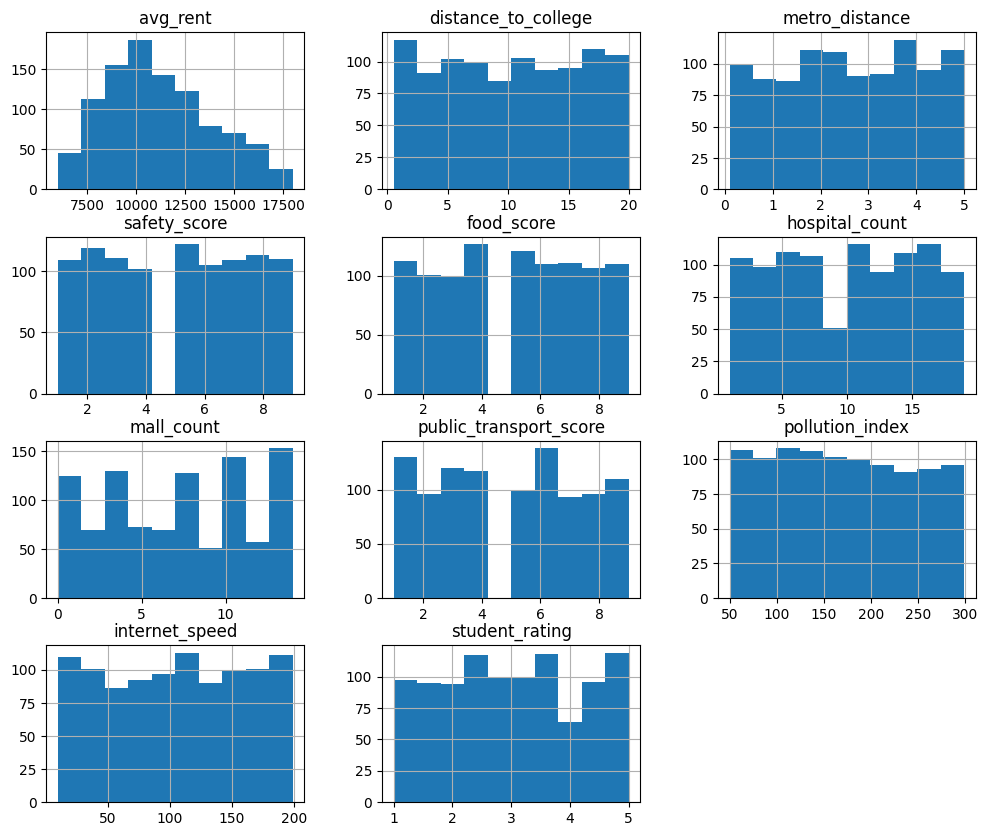

In [5]:
df.hist(figsize=(12,10))
plt.show()

**Correlation Analysis**

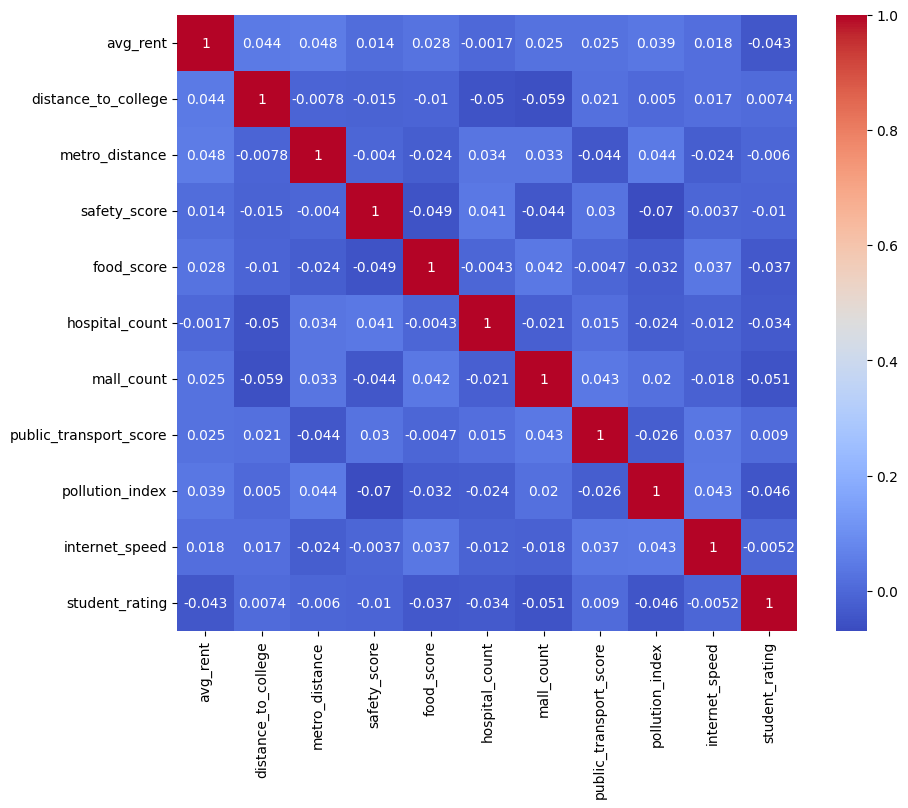

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

**Feature Engineering**

In [7]:
# Lower rent = better
df['rent_score'] = 1 / df['avg_rent']
# Closer distance = better
df['distance_score'] = 1 / df['distance_to_college']
df['metro_score'] = 1 / df['metro_distance']
# Lower pollution = better
df['pollution_score'] = 1 / df['pollution_index']

**Locality Scoring**

In [8]:
df['final_score'] = (
    df['rent_score'] * 0.2 +
    df['distance_score'] * 0.2 +
    df['metro_score'] * 0.15 +
    df['safety_score'] * 0.15 +
    df['food_score'] * 0.1 +
    df['public_transport_score'] * 0.1 +
    df['pollution_score'] * 0.1
)

**Creating Recommendation Labels**

In [9]:
df['recommended'] = df['final_score'].apply(lambda x: 1 if x > df['final_score'].median() else 0)

**Splitting Dataset into Train and Test Sets**

In [10]:
from sklearn.model_selection import train_test_split
features = [
    'avg_rent', 'distance_to_college', 'metro_distance',
    'safety_score', 'food_score', 'hospital_count',
    'mall_count', 'public_transport_score',
    'pollution_index', 'internet_speed'
]
X = df[features]
y = df['recommended']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model Training Setup**

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier()
}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name} Accuracy:", accuracy_score(y_test, preds))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Accuracy: 0.945
RandomForest Accuracy: 0.91


**Confusion Matrix and Classification Report**

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
preds = rf.predict(X_test)
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[87 10]
 [11 92]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.89        97
           1       0.90      0.89      0.90       103

    accuracy                           0.90       200
   macro avg       0.89      0.90      0.89       200
weighted avg       0.90      0.90      0.90       200



**Feature Importance Analysis**

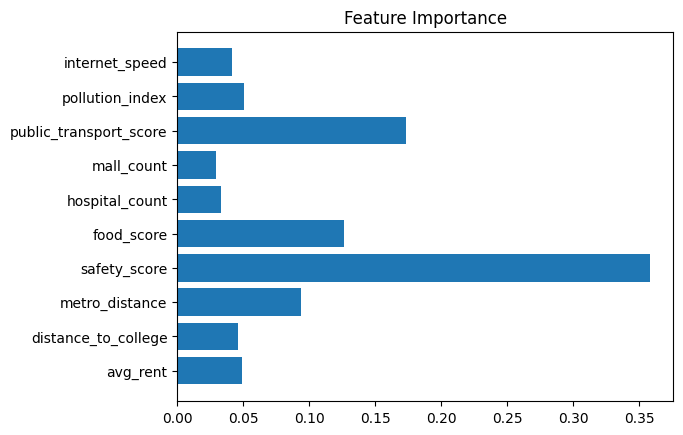

In [13]:
importance = rf.feature_importances_
feature_names = X.columns
plt.figure()
plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.show()

**Locality Recommendation Function**

In [14]:
def recommend_localities(df, budget):
    df_filtered = df[df['avg_rent'] <= budget]
    return df_filtered.sort_values(by='final_score', ascending=False).head(5)
recommend_localities(df, 10000)

,locality,city,avg_rent,distance_to_college,metro_distance,safety_score,food_score,hospital_count,mall_count,public_transport_score,pollution_index,internet_speed,student_rating,rent_score,distance_score,metro_score,pollution_score,final_score,recommended
577,Mukherjee Nagar,Delhi,8356,15.07,0.11,9,9,11,2,3,269,138,3.7,0.000120,0.066357,9.090909,0.003717,3.927303,1
856,Mukherjee Nagar,Delhi,9473,9.56,0.20,9,7,8,2,6,238,57,2.7,0.000106,0.104603,5.000000,0.004202,3.421362,1
195,Rohini,Delhi,9840,9.61,0.14,8,3,3,7,7,144,115,1.3,0.000102,0.104058,7.142857,0.006944,3.292955,1
478,Rohini,Delhi,7782,11.86,2.66,9,9,13,5,9,99,177,1.9,0.000129,0.084317,0.375940,0.010101,3.224290,1
443,Rohini,Delhi,7968,4.56,0.19,9,2,3,2,8,129,90,1.8,0.000126,0.219298,5.263158,0.007752,3.184134,1
